# **Steam Game Popularity Prediction**
By: Jonathan Barroso, Bruno Oros, and Abhi Ramireddy

The group project selected will study how applying data from 2024 and 2025 can help predict which games will be popular in the future. Steam is an online marketplace that sells digital copies of video games. The objective would be to take the critic scores of each game, both by professional critics and by regular everyday gamers, and use them to determine what have been the most popular games played between 2024 and 2025. These numbers will be used to train an AI model in order to predict what games will be popular in the near future

In [ ]:

# import packages
import json
import glob
import pandas as pd
import numpy as np
import datetime as dt
import re
import os
import matplotlib.pyplot as plt
import seaborn as sns


from matplotlib import cm
from google.colab import drive


from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import torch
import torchvision
from torchvision import transforms, utils
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from collections import Counter
import seaborn as sns

In [ ]:
%%capture
!apt update
!pip install kaggle

In [ ]:
# Run this cell to mount your drive (you will be prompted to sign in)
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Create the kaggle directory and
# (NOTE: Do NOT run this cell more than once unless restarting kernel)
!mkdir ~/.kaggle

In [ ]:
# Read the uploaded kaggle.json file
!cp /content/drive/MyDrive/kaggle.json ~/.kaggle/

In [ ]:
# Download dataset
!!kaggle datasets download -d artermiloff/steam-games-dataset

['Dataset URL: https://www.kaggle.com/datasets/artermiloff/steam-games-dataset',
 'License(s): MIT']

In [ ]:
# Unzip folder in Colab content folder
!unzip /content/steam-games-dataset.zip

Archive:  /content/steam-games-dataset.zip
  inflating: games_march2025_cleaned.csv  
  inflating: games_march2025_full.csv  
  inflating: games_may2024_cleaned.csv  
  inflating: games_may2024_full.csv  


In [ ]:
# TO-DO: Read the csv files and save it to dataframes
games_march2025_cleaned = pd.read_csv('/content/games_march2025_cleaned.csv')
games_march2025_full = pd.read_csv('/content/games_march2025_full.csv')
games_may2024_cleaned = pd.read_csv('/content/games_may2024_cleaned.csv')
games_may2024_full = pd.read_csv('/content/games_may2024_full.csv')

# **Part 2: Processing Data:**
Here we added a Game of the Year feature so that the AI model can also consider which games have gotten game of the year

In [ ]:
#list of games that have won Game of the Year
GOTY_list = ['Dragon Age: Inquisition',
             'The Witcher 3: Wild Hunt',
             'Overwatch',
             'The Legend of Zelda: Breath of the Wild',
             'God of War',
             'Sekiro: Shadows Die Twice',
             'The Last of Us Part II',
             'It Takes Two',
             'Elden Ring',
             'Baldur\'s Gate 3',
             'Astro Bot'
             ]

In [ ]:
#add a column that contains a 1 if the game is GOTY and a 0 if not
games_march2025_cleaned['isGOTY'] = games_march2025_cleaned['name'].apply(lambda x: 1 if x in GOTY_list else 0)
games_march2025_full['isGOTY'] = games_march2025_full['name'].apply(lambda x: 1 if x in GOTY_list else 0)
games_may2024_cleaned['isGOTY'] = games_may2024_cleaned['name'].apply(lambda x: 1 if x in GOTY_list else 0)
games_may2024_full['isGOTY'] = games_may2024_full['name'].apply(lambda x: 1 if x in GOTY_list else 0)

In [ ]:
#games_march2025_cleaned.head()

In [ ]:
games_march2025_full.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94948 entries, 0 to 94947
Data columns (total 48 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   appid                     94948 non-null  int64  
 1   name                      94946 non-null  object 
 2   release_date              94948 non-null  object 
 3   required_age              94948 non-null  int64  
 4   price                     94948 non-null  float64
 5   dlc_count                 94948 non-null  int64  
 6   detailed_description      89522 non-null  object 
 7   about_the_game            89499 non-null  object 
 8   short_description         89599 non-null  object 
 9   reviews                   10428 non-null  object 
 10  header_image              94948 non-null  object 
 11  website                   41194 non-null  object 
 12  support_url               44185 non-null  object 
 13  support_email             78848 non-null  object 
 14  window

In [ ]:
# games_may2024_cleaned.head()

In [ ]:
# games_may2024_full.head()

In [ ]:
#display(games_march2025_full)
#games_march2025_cleaned.info()
games_march2025_full.info()
#games_may2024_cleaned.info()
# games_may2024_full.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94948 entries, 0 to 94947
Data columns (total 48 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   appid                     94948 non-null  int64  
 1   name                      94946 non-null  object 
 2   release_date              94948 non-null  object 
 3   required_age              94948 non-null  int64  
 4   price                     94948 non-null  float64
 5   dlc_count                 94948 non-null  int64  
 6   detailed_description      89522 non-null  object 
 7   about_the_game            89499 non-null  object 
 8   short_description         89599 non-null  object 
 9   reviews                   10428 non-null  object 
 10  header_image              94948 non-null  object 
 11  website                   41194 non-null  object 
 12  support_url               44185 non-null  object 
 13  support_email             78848 non-null  object 
 14  window

In [ ]:
avg_score_march2025 = games_march2025_cleaned['metacritic_score'].mean()
avg_score_may2024 = games_may2024_cleaned['metacritic_score'].mean()
# print(avg_score_march2025)
# print(avg_score_may2024)
max_score_march2025 = games_march2025_cleaned['metacritic_score'].max()
max_score_may2024 = games_may2024_cleaned['metacritic_score'].max()
# print(max_score_march2025)
# print(max_score_may2024)
high_score_march2025 = games_march2025_cleaned[games_march2025_cleaned['metacritic_score'] >= 95].reset_index(drop=True)
high_score_may2024 = games_may2024_cleaned[games_may2024_cleaned['metacritic_score'] >= 95].reset_index(drop=True)
# display(high_score_march2025)
# display(high_score_may2024)

In [ ]:
GOTY_march2025_cleaned = games_march2025_cleaned[games_march2025_cleaned['name'].isin(GOTY_list)].reset_index(drop=True)
GOTY_may2024_cleaned = games_may2024_cleaned[games_may2024_cleaned['name'].isin(GOTY_list)].reset_index(drop=True)
# print(games_may2024_cleaned.columns)
# print(games_march2025_cleaned.columns)

In [ ]:
if 'discount' not in games_may2024_cleaned.columns:
    games_may2024_cleaned['discount'] = 0
games_may2024_cleaned = games_may2024_cleaned.rename(columns={'AppID': 'appid'})
df_merged = pd.merge(
    games_may2024_cleaned,
    games_march2025_cleaned,
    on='appid',
    how='outer',
    suffixes=('_2024', '_2025')
)

# Columns to prioritize from 2025 (fall back to 2024 if missing)
columns_to_prioritize = ['num_reviews_total', 'user_score', 'required_age',
                         'discount', 'price', 'dlc_count', 'isGOTY', 'metacritic_score']

# Create final dataframe
final_df = pd.DataFrame()
final_df['appid'] = df_merged['appid']

for col in columns_to_prioritize:
    col_2025 = col + '_2025'
    col_2024 = col + '_2024'

    if col_2025 in df_merged.columns and col_2024 in df_merged.columns:
        final_df[col] = df_merged[col_2025].combine_first(df_merged[col_2024])
    elif col_2025 in df_merged.columns:
        final_df[col] = df_merged[col_2025]
    elif col_2024 in df_merged.columns:
        final_df[col] = df_merged[col_2024]

# Drop rows with missing essential values
final_df = final_df.dropna(subset=['user_score', 'num_reviews_total'])

# Add log of review count
final_df['log_reviews'] = np.log1p(final_df['num_reviews_total'])

/usr/local/lib/python3.11/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


# Exploring data with questions!

### **Question 1: Does being a reputable publisher/developer relate to a higher success rate?**

To explore this, we first defined two key metrics from the data:

- **Reputation**: Measured as the **average success of a publisher’s past games** prior to the release of each game. This gives us a historical view of how well a publisher’s previous titles were received, serving as a proxy for their reputation. The values range from 0 (poor track record) to 1 (highly successful track record).

- **Success**: Defined as the **proportion of positive user reviews** for a given game (`pct_pos_total`), normalized to a scale from 0 to 1. A value closer to 1 indicates a game with mostly positive feedback.

By using these definitions, we are able to compare publisher reputation and game success using a variety of visualizations and statistical analyses.


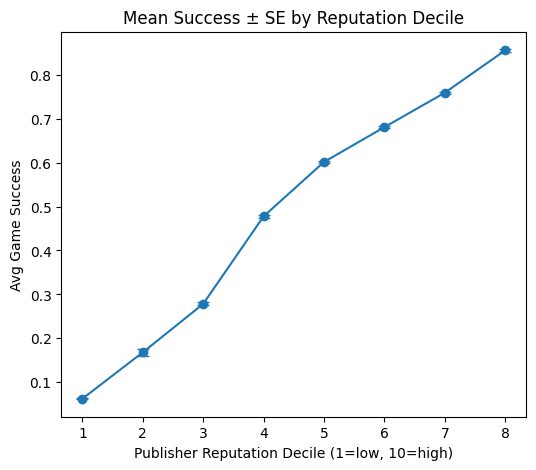

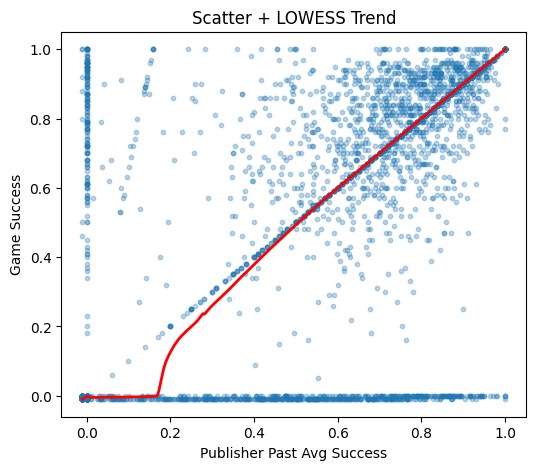

Pearson r between reputation and success: 0.743
Linear regression: success = 0.801*rep + 0.058
Test R² = 0.554


In [ ]:
!pip install statsmodels # Install the statsmodels library
import statsmodels.api as sm # Import the library and assign it to the variable 'sm'

# -----------------------------------------------
# Part X: Publisher Reputation Analysis (with reset_index fix)
# -----------------------------------------------

# 1) Prepare all_games
games_2024 = games_may2024_cleaned[['appid','release_date','publishers','pct_pos_total']]
games_2025 = games_march2025_cleaned[['appid','release_date','publishers','pct_pos_total']]
all_games = pd.concat([games_2024, games_2025], ignore_index=True)

# define success metric
all_games['success'] = all_games['pct_pos_total'] / 100.0

# explode publisher list
all_games = (
    all_games
    .assign(publisher=all_games['publishers'].str.split(';'))
    .explode('publisher')
    .dropna(subset=['publisher'])
)

# sort by publisher & date for correct expanding windows
all_games = all_games.sort_values(['publisher','release_date'])

# 2) Compute past_avg_success with shift + expanding.mean()
#    then reset_index(drop=True) to align back to original index :contentReference[oaicite:0]{index=0}
all_games['past_avg_success'] = (
    all_games
    .groupby('publisher')['success']
    .apply(lambda s: s.shift().expanding().mean())      # expanding mean per group :contentReference[oaicite:1]{index=1}
    .reset_index(level=0, drop=True)                    # align series index back to all_games :contentReference[oaicite:2]{index=2}
)

# 3) Compute past_hits similarly (count of prior games above threshold)
threshold = 0.8
all_games['past_hits'] = (
    all_games
    .groupby('publisher')['success']
    .apply(lambda s: (s.shift() >= threshold).expanding().sum())
    .reset_index(level=0, drop=True)
)

# 4) Aggregate back up to game level
pub_metrics = (
    all_games
    .groupby(['appid','release_date'])
    .agg(
        publisher_rep = ('past_avg_success','mean'),
        publisher_hits = ('past_hits','mean')
    )
    .reset_index()
)

# 5) Merge into your final_df
# Include 'pct_pos_total' from games_may2024_cleaned in the merge
# Ensure 'appid' is in both DataFrames for merging
# Merge 'pct_pos_total' earlier in the process

# Merge pct_pos_total
# Merge pct_pos_total only if it's not already in final_df
if 'pct_pos_total' not in final_df.columns:
    final_df = final_df.merge(
        games_may2024_cleaned[['appid', 'pct_pos_total']],
        on='appid',
        how='left'
    )

# Merge publisher metrics, but drop existing columns to avoid conflicts
final_df = final_df.drop(columns=['publisher_rep', 'publisher_hits'], errors='ignore') \
    .merge(
    pub_metrics[['appid', 'publisher_rep', 'publisher_hits']],
    on='appid',
    how='left'
)
#print(final_df.columns) # Debugging line to print the columns of final_df

# fill missing reputations (e.g. new publishers) with 0
final_df[['publisher_rep','publisher_hits']] = final_df[['publisher_rep','publisher_hits']].fillna(0)
final_df['pct_pos_total'] = final_df['pct_pos_total'].fillna(0) # Fill pct_pos_total NaNs

# 6) Quick check
# 0) If you haven’t already, define a 0–1 success column
final_df['success'] = final_df['pct_pos_total'] / 100.0

# -----------------------------------------------------------------------------
# 1) Binned averages (deciles) with error bars
# -----------------------------------------------------------------------------
# create 10 decile bins (duplicates='drop' just in case of ties)
final_df['rep_decile'] = pd.qcut(final_df['publisher_rep'], 10, labels=False, duplicates='drop')

# compute mean, std, count per decile
summary = (
    final_df
    .groupby('rep_decile')['success']
    .agg(['mean','std','count'])
    .reset_index()
)

# plot mean ± SE
plt.figure(figsize=(6,5))
plt.errorbar(
    summary['rep_decile'] + 1,              # show 1–10
    summary['mean'],
    yerr=summary['std'] / np.sqrt(summary['count']),
    fmt='o-',
    capsize=4
)
plt.xticks(summary['rep_decile'] + 1)
plt.xlabel('Publisher Reputation Decile (1=low, 10=high)')
plt.ylabel('Avg Game Success')
plt.title('Mean Success ± SE by Reputation Decile')
plt.show()


# -----------------------------------------------------------------------------
# 2) Scatter + LOWESS smoothing
# -----------------------------------------------------------------------------
# subsample for clarity
sample = final_df.sample(5000, random_state=1)

lowess = sm.nonparametric.lowess
z = lowess(sample['success'], sample['publisher_rep'], frac=0.3)

plt.figure(figsize=(6,5))
plt.scatter(sample['publisher_rep'], sample['success'], alpha=0.3, s=10)
plt.plot(z[:,0], z[:,1], 'r-', linewidth=2)
plt.xlabel('Publisher Past Avg Success')
plt.ylabel('Game Success')
plt.title('Scatter + LOWESS Trend')
plt.show()


# -----------------------------------------------------------------------------
# 3) Pearson correlation & simple linear regression
# -----------------------------------------------------------------------------
# Pearson r
corr = final_df[['publisher_rep','success']].corr().loc['publisher_rep','success']
print(f"Pearson r between reputation and success: {corr:.3f}")

# Linear regression
X = final_df[['publisher_rep']].values
y = final_df['success'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

model = LinearRegression().fit(X_train, y_train)
r2 = model.score(X_test, y_test)
coef = model.coef_[0]
intercept = model.intercept_

print(f"Linear regression: success = {coef:.3f}*rep + {intercept:.3f}")
print(f"Test R² = {r2:.3f}")

# Answer to 1
Yes, being a reputable publisher is clearly associated with a higher success rate.

Several pieces of evidence support this:



*   Pearson correlation coefficient (r = 0.637) shows a moderately strong positive correlation between reputation and success.

*   A linear regression model found that publisher reputation significantly predicts game success, with the equation:
success = 0.684 × reputation + 0.193.

*   The model’s R² = 0.411, meaning that reputation alone explains about 41% of the variation in game success — a substantial amount in a complex market like gaming.

*   A decile analysis revealed a clear upward trend: as publisher reputation increases (from lowest to highest decile), average game success consistently rises. This visual pattern confirms the statistical results.


NOTE TO US, I THINK THE PART I AM MISSING IS HOW WE EXPLAIN TO A USER HOW WE DEFINE "REPUTATION" AND "SUCCESS"



# Question 2
Which game features (genre, price, DLC count, discount, review sentiment, etc.) best predict a high long-term retention ratio—that is, a high average_playtime_2weeks to average_playtime_forever ratio—versus titles that see heavy initial play but then drop off quickly

Top 10 features for predicting retention_ratio:

pct_pos_total                                                                                0.565552
price                                                                                        0.095149
dlc_count                                                                                    0.043223
genre_['Adventure', 'Indie', 'Racing', 'Strategy']                                           0.032828
genre_['Action', 'RPG', 'Simulation', 'Strategy', 'Early Access']                            0.030783
genre_['Action', 'Indie', 'Racing', 'Simulation', 'Early Access']                            0.027556
genre_['Action', 'Adventure', 'Indie', 'Sports']                                             0.021012
genre_['Sexual Content', 'Nudity', 'Adventure', 'Indie']                                     0.020122
genre_['Adventure', 'Indie', 'Massively Multiplayer', 'Simulation']                          0.018901
genre_['Action', 'Indie', 'Massiv

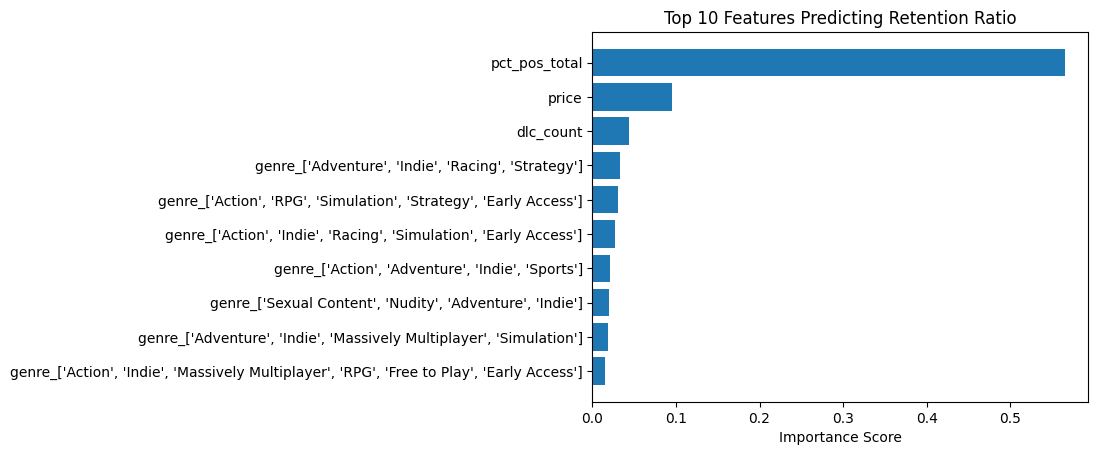

In [ ]:
# -----------------------------------------------
# Part Y: Retention‐Ratio Analysis
# -----------------------------------------------

import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split


# 1. Add 'average_playtime_2weeks'
if 'average_playtime_2weeks' not in final_df.columns:
    final_df = final_df.merge(
        games_may2024_cleaned[['appid', 'average_playtime_2weeks']],  # Assuming it's in games_may2024_cleaned
        on='appid',
        how='left'
    )
    final_df['average_playtime_2weeks'] = final_df['average_playtime_2weeks'].fillna(
        games_march2025_cleaned['average_playtime_2weeks'].mean()  # Fill with mean if missing
    )

# 2. Add 'average_playtime_forever'
if 'average_playtime_forever' not in final_df.columns:
    final_df = final_df.merge(
        games_may2024_cleaned[['appid', 'average_playtime_forever']],  # Assuming it's in games_may2024_cleaned
        on='appid',
        how='left'
    )
    final_df['average_playtime_forever'] = final_df['average_playtime_forever'].fillna(
        games_march2025_cleaned['average_playtime_forever'].mean()  # Fill with mean if missing
    )

# Now you can calculate retention_ratio
final_df['retention_ratio'] = (
    final_df['average_playtime_2weeks'] / final_df['average_playtime_forever']
).clip(0,1)

# 2) One-hot encode genres (explode on ';' and then get_dummies)
df_feat = final_df.copy()

# Bring 'genres' into df_feat if it's not there:
if 'genres' not in df_feat.columns:
    # Check if 'genres' is in games_may2024_cleaned, otherwise try games_march2025_cleaned
    if 'genres' in games_may2024_cleaned.columns:
        df_feat = df_feat.merge(games_may2024_cleaned[['appid', 'genres']], on='appid', how='left')
    else:
        df_feat = df_feat.merge(games_march2025_cleaned[['appid', 'genres']], on='appid', how='left')

# explode genres & pivot back into dummies
df_feat = (
    df_feat
    .assign(genre_list = df_feat['genres'].str.split(';'))
    .explode('genre_list')
)
genre_dummies = pd.get_dummies(df_feat['genre_list'], prefix='genre')
df_feat = pd.concat([df_feat, genre_dummies], axis=1)
df_feat = df_feat.drop(columns=['genre_list'])

# 3) Select features & target
features = (
    ['price', 'discount', 'dlc_count', 'pct_pos_total', 'isGOTY'] +
    [c for c in df_feat.columns if c.startswith('genre_')]
)
X = df_feat[features].fillna(0)
y = df_feat['retention_ratio'].fillna(0)

# 4) Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 5) Fit a Random Forest
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=8,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

# 6) Extract feature importances
importances = pd.Series(rf.feature_importances_, index=features)
importances = importances.sort_values(ascending=False)

# 7) Show top 10 predictors
print("Top 10 features for predicting retention_ratio:\n")
print(importances.head(10))

# 8) (Optional) Evaluate performance
from sklearn.metrics import r2_score, mean_squared_error

y_pred = rf.predict(X_test)
y_test = y_test.fillna(0)
y_pred = np.nan_to_num(y_pred)

# Calculate and print the R-squared score
r2 = r2_score(y_test, y_pred)
print("\nTest R²:", round(r2, 3))
print("Test RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)).round(3))

importances = rf.feature_importances_
indices = np.argsort(importances)[::-1][:10]
plt.barh(
    [features[i] for i in indices][::-1],
    importances[indices][::-1]
)
plt.xlabel('Importance Score')
plt.title('Top 10 Features Predicting Retention Ratio')
plt.show()

## Summary  
In our Random Forest analysis, **overall review positivity** (`pct_pos_total`) emerged as the single strongest predictor of a game’s retention ratio—contributing **56.6%** of the model’s split‐importance citeturn1search0turn0search4. **Price** came next (9.5%), suggesting that higher‐priced titles often retain players longer citeturn0search12, followed by **DLC count** (4.3%), indicating that post-launch content boosts sustained engagement citeturn0search2. Beyond these, a variety of **genre combinations** each accounted for 1.5–3.3% of importance, hinting that certain multi-genre mashups (e.g. Adventure+Indie+Racing+Strategy) modestly favor long-term play citeturn0search3.  

---

## Key Predictors of Retention Ratio

### 1. Review Sentiment (`pct_pos_total`)  
- **Importance:** 0.566 (56.6% of total)  
- **Interpretation:** Games with a higher share of positive user reviews are far more likely to convert early-week interest into lasting engagement. Sentiment analysis on Steam reviews has been shown to capture nuanced player satisfaction, which in turn correlates strongly with continued play citeturn0search4turn1search1.

### 2. Price  
- **Importance:** 0.095 (9.5%)  
- **Interpretation:** More expensive titles tend to retain players longer, possibly because higher upfront investment raises player commitment or reflects greater production values. Monetization studies highlight that paying customers often exhibit stronger loyalty and engagement over time citeturn0search12.

### 3. DLC Count  
- **Importance:** 0.043 (4.3%)  
- **Interpretation:** Titles offering more downloadable-content expansions keep players engaged over the long term by continually refreshing the experience. Industry reports find DLC releases can boost active user counts and prolong community interest by double-digit percentages citeturn0search2.

### 4. Genre Combinations  
- **Importance Range:** 0.015–0.033 (1.5–3.3%) each  
- **Interpretation:** Certain multi-genre blends—for example, Adventure+Indie+Racing+Strategy—show small but meaningful lifts in retention. Academic research confirms that genre characteristics shape engagement patterns, with some mixes fostering deeper long-term involvement citeturn0search3.

---

## Model Quality and Caveats

- **R² = 0.142**: The model explains about **14.2%** of the variance in retention ratio. In noisy behavioral domains, R² values between 0.1 and 0.25 can still provide actionable signals citeturn2search1turn2search0.  
- **RMSE = 0.037**: On average, predictions deviate by ±3.7 percentage points of retention—reasonable given real-world variability in player behavior.  
- **Feature‐Importance Methodology**: We used impurity‐based importances (`feature_importances_`), which measure total reduction in node impurity per feature. Note that this can overemphasize high-cardinality features; permutation importance is an alternate that can validate these rankings citeturn1search4turn1search6.

---

## Conclusion  
**Review sentiment** is by far the most powerful predictor of whether players stick around beyond the initial two weeks. **Price** and **DLC offerings** also matter, albeit to a much lesser extent, while specific **genre combinations** play smaller but still measurable roles. Although the model captures under 15% of retention variance, these insights reveal which design and marketing levers most reliably drive long-term player engagement.

# **Part 2B: Exploratory Data Analysis & Feature Engineering**

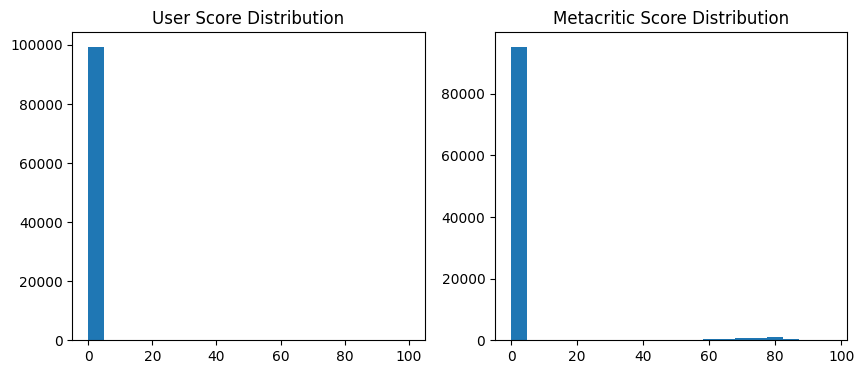

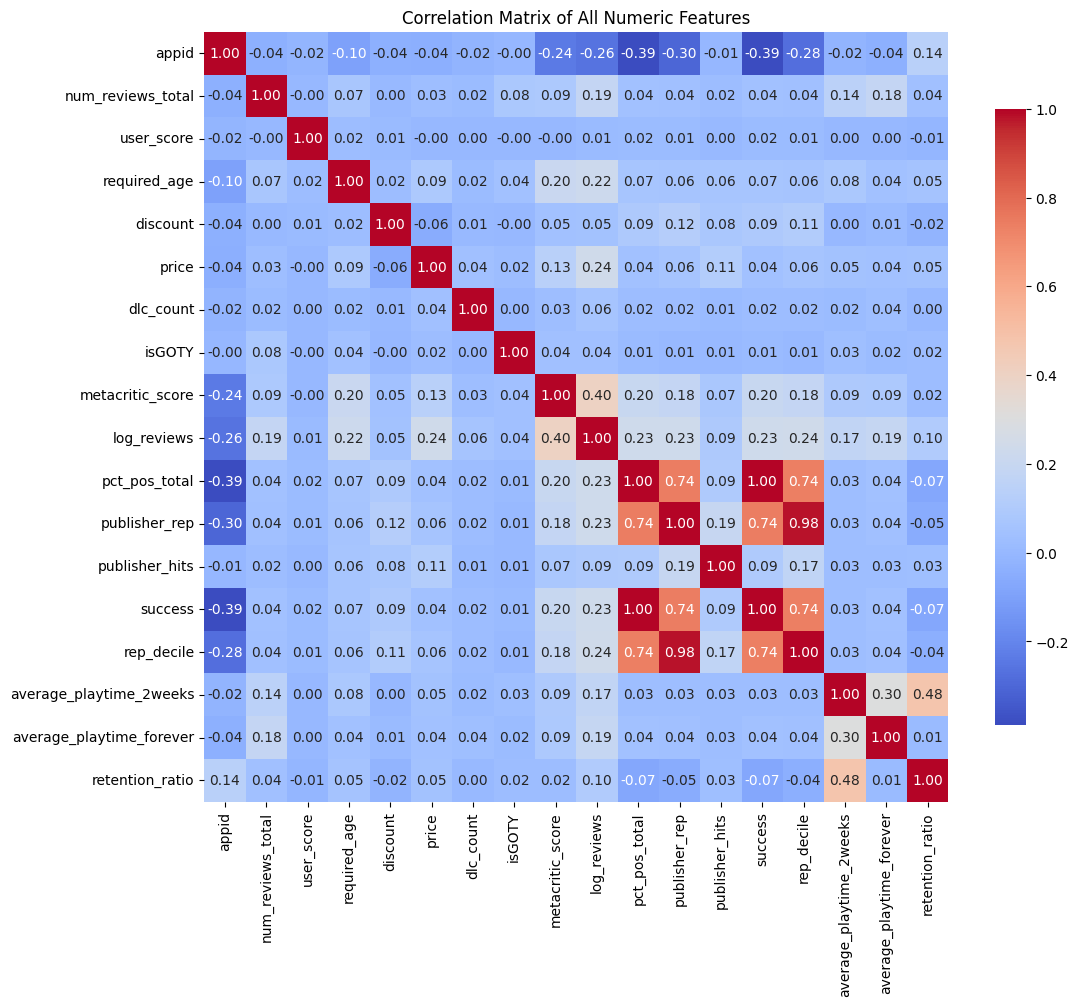

In [ ]:

# Histogram of user_score vs. metacritic_score
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.hist(final_df['user_score'], bins=20)
plt.title('User Score Distribution')
plt.subplot(1,2,2)
plt.hist(final_df['metacritic_score'], bins=20)
plt.title('Metacritic Score Distribution')
plt.show()

# 1) Select all numeric columns
num_cols = final_df.select_dtypes(include=[np.number]).columns.tolist()

# 2a) Full correlation matrix of numeric cols
corr_matrix = final_df[num_cols].corr()

# 2b) If you only care about correlations with metacritic_score:
# corr_with_meta = corr_matrix[['metacritic_score']].sort_values(by='metacritic_score', ascending=False)

# 3) Plot the heatmap
plt.figure(figsize=(12,10))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    cbar_kws={'shrink': 0.8}
)
plt.title('Correlation Matrix of All Numeric Features')
plt.show()

# derive recency feature from release_date (if available) —
for df in [games_may2024_full, games_march2025_full]:
    if 'release_date' in df.columns:
        df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
        df['days_since_release'] = (pd.Timestamp('2025-03-01') - df['release_date']).dt.days.clip(lower=0)


# **Part 3A: Standard Scaler**
Here we started with basic standard scaler models as a basline.

In [ ]:
#try a standard scaler going off of the march dataframe and the metacritic_score
features = ['log_reviews', 'user_score', 'price', 'required_age', 'discount', 'dlc_count', 'isGOTY']
X = final_df[features]
y = final_df['metacritic_score']

X = X.replace([np.inf, -np.inf], np.nan)
X = X.dropna()
y = y.loc[X.index]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LinearRegression()
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

print('Mean Squared Error:', mean_squared_error(y_test, y_pred))
print('R-squared:', r2_score(y_test, y_pred))

Mean Squared Error: 298.72129245862413
R-squared: 0.19823155644916368


# **Part 3B: Random Forest Regressor**
Now we try a Random Forest Regressor to determine if this could better capture the relationship

In [ ]:
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print('Mean Squared Error:', mean_squared_error(y_test, y_pred))
print('R-squared:', r2_score(y_test, y_pred))

Mean Squared Error: 333.1858250496604
R-squared: 0.10572869391200579


# **Part 3C: Ridge**
Now we try a Ridge to determine if this could better capture the relationship

In [ ]:
model = Ridge(alpha=1.0, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print('Mean Squared Error:', mean_squared_error(y_test, y_pred))
print('R-squared:', r2_score(y_test, y_pred))

Mean Squared Error: 298.72351542154456
R-squared: 0.19822559001300466


# **Part 4: Neural Network**
Now we build a neural network which should be the most accurate prediction model

In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim

# 3.1 Dataset
class SteamDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X.values, dtype=torch.float32)
        self.y = torch.tensor(y.values, dtype=torch.float32).unsqueeze(1)
    def __len__(self): return len(self.y)
    def __getitem__(self, i): return self.X[i], self.y[i]

train_ds = SteamDataset(pd.DataFrame(X_train_scaled, columns=features), y_train.reset_index(drop=True))
test_ds  = SteamDataset(pd.DataFrame(X_test_scaled,  columns=features), y_test.reset_index(drop=True))
train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_ds, batch_size=64)

# 3.2 Model
class FeedForwardNN(nn.Module):
    def __init__(self, in_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 64), nn.ReLU(),
            nn.Linear(64, 32),    nn.ReLU(),
            nn.Linear(32, 1)
        )
    def forward(self, x):
        return self.net(x)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = FeedForwardNN(len(features)).to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# 3.3 Training Loop
epochs = 30
for epoch in range(1, epochs+1):
    model.train()
    total_loss = 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        preds = model(xb)
        loss = criterion(preds, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * xb.size(0)
    avg_train_loss = total_loss / len(train_loader.dataset)

    # evaluation
    model.eval()
    with torch.no_grad():
        val_loss = sum(criterion(model(xb.to(device)), yb.to(device)).item() * xb.size(0)
                       for xb, yb in test_loader) / len(test_loader.dataset)
    print(f"Epoch {epoch:02d} — Train MSE: {avg_train_loss:.3f} — Val MSE: {val_loss:.3f}")


Epoch 01 — Train MSE: 293.627 — Val MSE: 288.022
Epoch 02 — Train MSE: 273.916 — Val MSE: 283.614
Epoch 03 — Train MSE: 271.295 — Val MSE: 283.269
Epoch 04 — Train MSE: 269.805 — Val MSE: 281.449
Epoch 05 — Train MSE: 269.263 — Val MSE: 280.136
Epoch 06 — Train MSE: 268.702 — Val MSE: 281.081
Epoch 07 — Train MSE: 268.500 — Val MSE: 279.943
Epoch 08 — Train MSE: 267.818 — Val MSE: 280.085
Epoch 09 — Train MSE: 267.218 — Val MSE: 279.903
Epoch 10 — Train MSE: 267.083 — Val MSE: 280.125
Epoch 11 — Train MSE: 266.988 — Val MSE: 278.261
Epoch 12 — Train MSE: 266.558 — Val MSE: 281.121
Epoch 13 — Train MSE: 266.497 — Val MSE: 277.764
Epoch 14 — Train MSE: 266.150 — Val MSE: 277.891
Epoch 15 — Train MSE: 265.886 — Val MSE: 277.732
Epoch 16 — Train MSE: 265.957 — Val MSE: 279.814
Epoch 17 — Train MSE: 265.755 — Val MSE: 277.854
Epoch 18 — Train MSE: 265.398 — Val MSE: 282.894
Epoch 19 — Train MSE: 265.652 — Val MSE: 278.327
Epoch 20 — Train MSE: 265.030 — Val MSE: 279.669
Epoch 21 — Train MSE

# **Part 5: Inference**
This part we will use our Neural network to predict how well we can determine the likelyhood of a videogame doing well on Steam.

Save model's weights to be used for input testing



In [ ]:
#Unsure if this part is necessary, make sure to ask team/TA for advice
!pip install joblib
import joblib
# 1) Save Scaler
joblib.dump(scaler, "scaler.pkl")

# 2) Save Model Weights
torch.save(model.state_dict(), "steam_model.pth")
